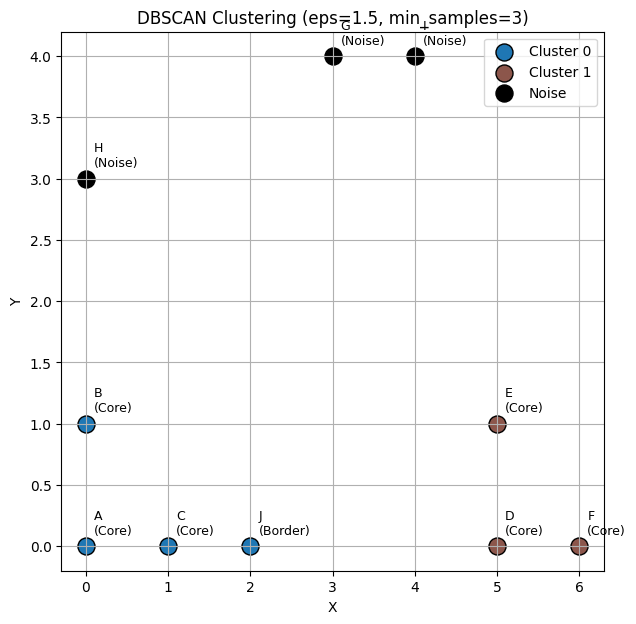

Point A is a Core point in Cluster 0
Point B is a Core point in Cluster 0
Point C is a Core point in Cluster 0
Point D is a Core point in Cluster 1
Point E is a Core point in Cluster 1
Point F is a Core point in Cluster 1
Point G is Noise
Point H is Noise
Point I is Noise
Point J is a Border point in Cluster 0


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# ---- Step 1: Define points ----
points = np.array([
    [0, 0],  # A
    [0, 1],  # B
    [1, 0],  # C
    [5, 0],  # D
    [5, 1],  # E
    [6, 0],  # F
    [3, 4],  # G
    [0, 3],  # H
    [4, 4],  # I
    [2, 0]   # J (new point to create border)
])

labels_names = ["A","B","C","D","E","F","G","H","I","J"]

# ---- Step 2: Run DBSCAN ----
eps = 1.5
min_samples = 3
db = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
labels = db.labels_

# ---- Step 3: Identify core, border, noise ----
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

point_type = []
for i in range(len(points)):
    if labels[i] == -1:
        point_type.append("Noise")
    elif core_samples_mask[i]:
        point_type.append("Core")
    else:
        point_type.append("Border")

# ---- Step 4: Plot results ----
plt.figure(figsize=(7,7))
unique_labels = set(labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # black for noise
    class_member_mask = (labels == k)
    xy = points[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], s=150, edgecolors='k', label=f'Cluster {k}' if k != -1 else 'Noise')

# annotate with names and types
for (x, y), name, t in zip(points, labels_names, point_type):
    plt.text(x+0.1, y+0.1, f"{name}\n({t})", fontsize=9)

plt.title(f"DBSCAN Clustering (eps={eps}, min_samples={min_samples})")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

# ---- Step 5: Print results ----
for name, label, t in zip(labels_names, labels, point_type):
    if label == -1:
        print(f"Point {name} is Noise")
    else:
        print(f"Point {name} is a {t} point in Cluster {label}")

